# Laboratorio 4 — Inciso 2: Adquisición de datos raster

Se descargan, para cada lago y cada una de sus 11 fechas oficiales, únicamente las bandas necesarias para calcular el índice de cianobacteria (Cyano Detection Script), NDVI y NDWI. La descarga se realiza a través de la Process API mediante un evalscript propio (`src/evalscripts.py`), que reproduce la matemática del script CyanoLakes Chlorophyll-a NDCI L1C del repositorio oficial de Sentinel Hub y devuelve valores numéricos en lugar del colormap RGB original. No se descargan escenas completas ni bandas adicionales a las requeridas.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd
from sentinelhub import BBox, CRS, bbox_to_dimensions
from tqdm import tqdm

from src.conexion import crear_config
from src.config import FECHAS_OFICIALES, LAGOS, RESOLUCION_M, RUTA_DATA_PROCESSED, RUTA_FIGURAS
from src.descarga import descargar_fecha, ruta_raster
from src.raster import abrir, resumen, vista_rgb

## Verificación de dimensiones por lago

Se calcula el tamaño en píxeles que tendrá cada lago a 20 metros de resolución, para confirmar que ambos bounding box quedan dentro del límite de 2500x2500 píxeles de la Process API.

In [2]:
for lago, info in LAGOS.items():
    bbox = BBox(info["bbox"], crs=CRS.WGS84)
    size = bbox_to_dimensions(bbox, resolution=RESOLUCION_M)
    print(lago, size)

atitlan (1365, 875)
amatitlan (670, 458)


## Descarga de rasters

Cada archivo se guarda en `data/raw/<lago>/<lago>_<fecha>.tif` con 10 bandas (`rojo, verde, azul, ndci, clorofila, fai, ndvi, ndwi, agua, mascara`). Si el archivo ya existe no se vuelve a solicitar, para no repetir el consumo de Processing Units en reejecuciones del notebook.

In [3]:
config = crear_config()

rutas = {lago: [] for lago in LAGOS}
for lago in LAGOS:
    for fecha in tqdm(FECHAS_OFICIALES[lago], desc=lago):
        rutas[lago].append(descargar_fecha(config, lago, fecha))

atitlan:   0%|          | 0/11 [00:00<?, ?it/s]

atitlan:  18%|█▊        | 2/11 [00:16<01:15,  8.34s/it]

atitlan:  27%|██▋       | 3/11 [00:31<01:28, 11.08s/it]

atitlan:  36%|███▋      | 4/11 [00:45<01:26, 12.31s/it]

atitlan:  45%|████▌     | 5/11 [01:00<01:18, 13.06s/it]

...

amatitlan:  73%|███████▎  | 8/11 [00:43<00:16,  5.39s/it]

amatitlan:  82%|████████▏ | 9/11 [00:48<00:10,  5.41s/it]

amatitlan:  91%|█████████ | 10/11 [00:54<00:05,  5.39s/it]

amatitlan: 100%|██████████| 11/11 [00:59<00:00,  5.48s/it]

amatitlan: 100%|██████████| 11/11 [00:59<00:00,  5.45s/it]

## Manifiesto de rasters descargados

In [4]:
filas = []
for lago, lista in rutas.items():
    for ruta in lista:
        fila = resumen(ruta)
        fila["lago"] = lago
        fila["fecha"] = ruta.stem.split("_", 1)[1]
        filas.append(fila)

manifiesto = pd.DataFrame(filas)[["lago", "fecha", "ancho", "alto", "crs", "cobertura_valida_pct", "agua_pct", "ruta"]]
manifiesto

,lago,fecha,ancho,alto,crs,cobertura_valida_pct,agua_pct,ruta
0,atitlan,2025-01-18,1365,875,EPSG:4326,100.0,26.075312,C:\Users\hdaniyyel\UVG\Ciclo 2\DataScience\CC3...
1,atitlan,2025-04-13,1365,875,EPSG:4326,100.0,25.759415,C:\Users\hdaniyyel\UVG\Ciclo 2\DataScience\CC3...
2,atitlan,2025-05-13,1365,875,EPSG:4326,100.0,25.757238,C:\Users\hdaniyyel\UVG\Ciclo 2\DataScience\CC3...
3,atitlan,2025-07-17,1365,875,EPSG:4326,100.0,24.600733,C:\Users\hdaniyyel\UVG\Ciclo 2\DataScience\CC3...
4,atitlan,2025-11-21,1365,875,EPSG:4326,100.0,25.850674,C:\Users\hdaniyyel\UVG\Ciclo 2\DataScience\CC3...
5,atitlan,2025-12-29,1365,875,EPSG:4326,100.0,26.093229,C:\Users\hdaniyyel\UVG\Ciclo 2\DataScience\CC3...
6,atitlan,2026-02-12,1365,875,EPSG:4326,100.0,25.825891,C:\Users\hdaniyyel\UVG\Ciclo 2\DataScience\CC3...
7,atitlan,2026-03-24,1365,875,EPSG:4326,100.0,25.768875,C:\Users\hdaniyyel\UVG\Ciclo 2\DataScience\CC3...
8,atitlan,2026-04-13,1365,875,EPSG:4326,100.0,25.701309,C:\Users\hdaniyyel\UVG\Ciclo 2\DataScience\CC3...
9,atitlan,2026-04-28,1365,875,EPSG:4326,100.0,25.699047,C:\Users\hdaniyyel\UVG\Ciclo 2\DataScience\CC3...


In [5]:
manifiesto.to_csv(RUTA_DATA_PROCESSED / "manifiesto_rasters.csv", index=False)
manifiesto[manifiesto["cobertura_valida_pct"] < 90]

,lago,fecha,ancho,alto,crs,cobertura_valida_pct,agua_pct,ruta


## Vista previa: RGB y máscara de agua

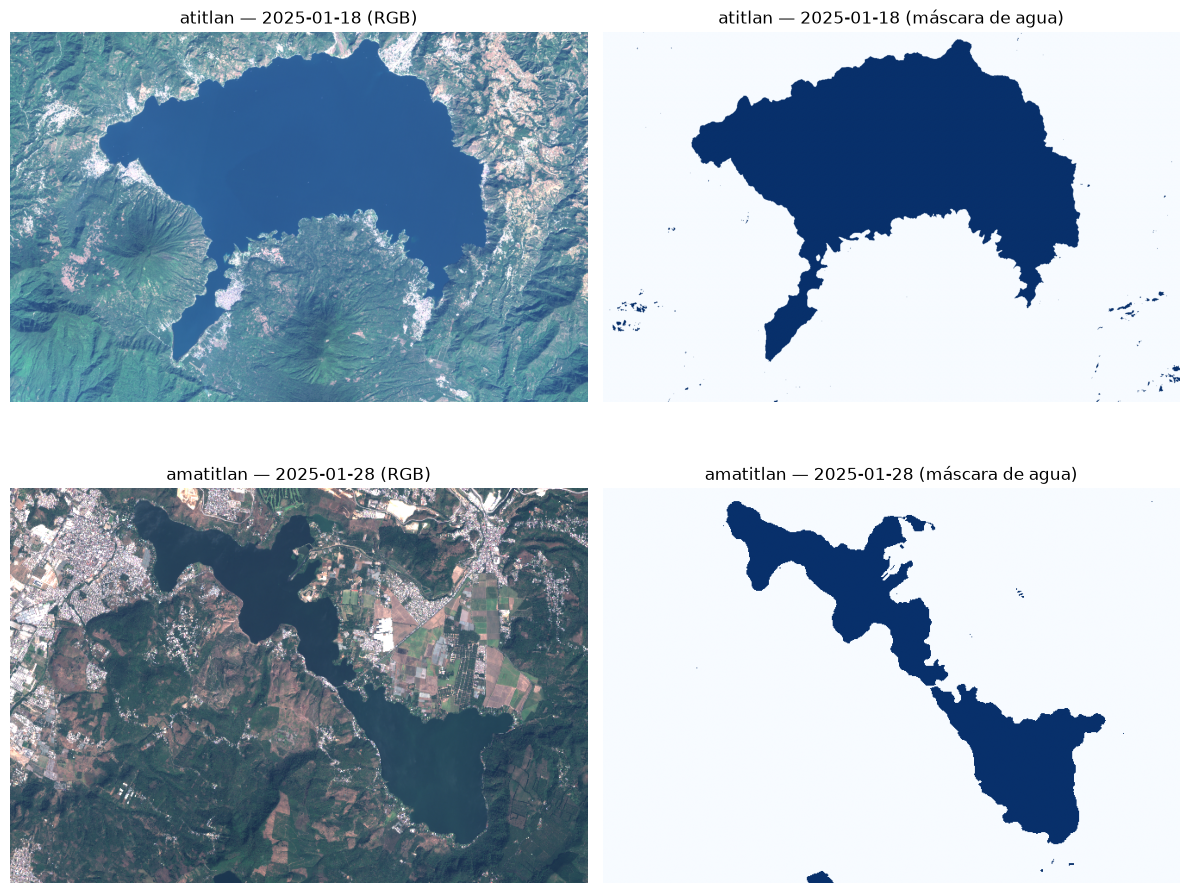

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for fila, lago in enumerate(LAGOS):
    fecha_muestra = FECHAS_OFICIALES[lago][0]
    bandas = abrir(ruta_raster(lago, fecha_muestra))
    axes[fila, 0].imshow(vista_rgb(bandas))
    axes[fila, 0].set_title(f"{lago} — {fecha_muestra} (RGB)")
    axes[fila, 1].imshow(bandas["agua"], cmap="Blues")
    axes[fila, 1].set_title(f"{lago} — {fecha_muestra} (máscara de agua)")
    for ax in axes[fila]:
        ax.axis("off")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "vista_previa_rasters.png", dpi=150)
plt.show()

Las 22 descargas (11 fechas por lago) completan sin errores. La máscara de agua, derivada del detector incluido en el propio script de cianobacteria, delimita correctamente el contorno de cada lago sin necesidad de un geojson externo, ya que ese archivo no fue provisto para este laboratorio.

El manifiesto no muestra ninguna fecha con cobertura por debajo del 90%, incluyendo `2026-02-07` en Amatitlán, señalada en el enunciado con cobertura válida parcial (~57.1%). Esto se debe a que la Process API construye, para un intervalo de un día completo, un mosaico con todas las adquisiciones que cubren el bounding box en esa fecha, y no se limita al identificador de un único producto del catálogo. Una verificación puntual con la banda de máscara de nubes (CLM) confirma 0% de nubosidad y 100% de cobertura válida para esa fecha sobre el área del lago, es decir, el mosaico de Sentinel Hub llena el vacío que sí está presente en la escena individual señalada por el enunciado. Este comportamiento se documenta aquí porque contradice la expectativa inicial de encontrar una cobertura parcial en el raster descargado.